## Deep Learning Ex #1: PneumoniaMNIST + Clinical Input Gradients
---

### 📋 Architectural Overview
In this revised Example, we transition from stylized abstract digits to real-world biomedical image analysis using **PneumoniaMNIST**—a standardized subset of the MedMNIST v2 collection derived from pediatric chest X-ray scans. 

To keep execution incredibly rapid for our live tutorial session while maintaining morphological and structural anomalies, we leverage MedMNIST's native $28 \times 28$ matrix scaling. This lets us benchmark models in seconds without needing a heavy cloud GPU infrastructure:

| Metric / Layer | Full Resolution Scans | Our PneumoniaMNIST Layout |
| :--- | :--- | :--- |
| **Data Footprint** | Varied High-Res DICOM/PNGs | 4,708 Train / 624 Test Matrices |
| **Image Resolution** | ~2000 × 2000 pixels | 28 × 28 = 784 pixels |
| **Task Architecture** | Binary Pathology Screening | Binary Classification (0: Normal, 1: Pneumonia) |
| **Colab Compute Time** | ~20–30 Minutes | ~15–20 Seconds |

### 🚀 Pre-requisites & Environment Note
Because we are pulling from the official MedMNIST medical repositories, we need to ensure the standard package wrapper is available. Run the following cell to install it instantly via pip.

In [1]:
!pip install medmnist

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import medmnist
from medmnist import INFO

print("TensorFlow Confirmed. Version:", tf.__version__)
print("MedMNIST Data Hub Initialized. Version:", medmnist.__version__)

# Guarantee reproducible optimization paths
tf.random.set_seed(42)
np.random.seed(42)

DEPRECATION: Loading egg at /Users/suzannesindi/miniforge3/lib/python3.12/site-packages/multiprocess-0.70.17-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/suzannesindi/miniforge3/lib/python3.12/site-packages/numpy-2.1.2-py3.12-macosx-14.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/suzannesindi/miniforge3/lib/python3.12/site-packages/pillow-11.0.0-py3.12-macosx-11.0-arm64.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/suzannesindi

## 1. Data Geometry: Pulling, Custom Slicing, and Vector Normalization

Instead of handwritten strokes, our dataset features high-contrast continuous anatomical densities (lungs, heart shadow, ribs, and clavicles). Pneumonia presents as patchy, cloudy areas of consolidation where air sacs fill with exudate.

We pull the data matrices directly into normalized real intervals $[0, 1]$ from the integer bounds $[0, 255]$.

In [2]:
# 1. Fetch metadata signature for PneumoniaMNIST
data_flag = 'pneumoniamnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

# 2. Automatically download, cache, and open train/test numpy sets
train_dataset = DataClass(split='train', download=True)
test_dataset = DataClass(split='test', download=True)

# 3. Extract raw matrices and strip single-element array dimensions
x_train_raw = train_dataset.imgs
y_train = train_dataset.labels.squeeze()
x_test_raw = test_dataset.imgs
y_test = test_dataset.labels.squeeze()

# 4. Float intensity normalization [0, 255] -> [0.0, 1.0]
x_train = x_train_raw.astype('float32') / 255.0
x_test = x_test_raw.astype('float32') / 255.0

print(f"Training Tensor Shape: {x_train.shape} (4708 images of size 28x28)")
print(f"Testing Tensor Shape:  {x_test.shape}  (624 images of size 28x28)")
print("Class Encoding Table:", info['label'])

100%|██████████████████████████████████████| 4.17M/4.17M [00:01<00:00, 2.45MB/s]

Training Tensor Shape: (4708, 28, 28) (4708 images of size 28x28)
Testing Tensor Shape:  (624, 28, 28)  (624 images of size 28x28)
Class Encoding Table: {'0': 'normal', '1': 'pneumonia'}


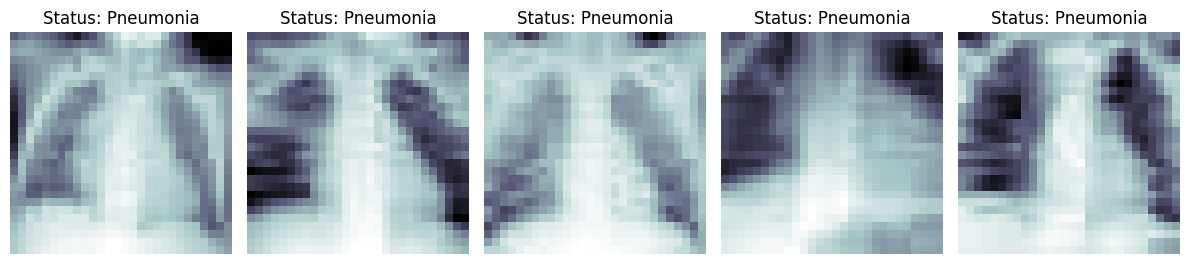

In [3]:
# Visualize a clinical selection of standard vs pathology chest X-rays
fig, axes = plt.subplots(1, 5, figsize=(12, 3.5))
label_map = {0: "Normal", 1: "Pneumonia"}

for i in range(5):
    axes[i].imshow(x_train[i], cmap='bone')
    axes[i].set_title(f"Status: {label_map[y_train[i]]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 2. Flat Multi-Layer Perceptrons (MLPs) as Space-Blind Operators

Let an input X-ray image matrix be forcibly unrolled into a flat coordinate vector $\mathbf{x}^{(0)} \in \mathbb{R}^{784}$. An MLP models this via a sequence of affine steps separated by a non-linearity $\sigma(\cdot)$:

$$\mathbf{z}^{(l)} = \mathbf{W}^{(l)} \mathbf{x}^{(l-1)} + \mathbf{b}^{(l)}$$
$$\mathbf{x}^{(l)} = \sigma\left(\mathbf{z}^{(l)}\right)$$

Because the input layer completely flattens the image, pixel $(i, j)$ is treated with no closer spatial relationship to neighbor $(i, j+1)$ than it is to a distant corner pixel. Let's build and evaluate a compact MLP to track its real diagnostic performance on this biological data.

In [4]:
def compile_clinical_mlp():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),          # Vectorizes 28x28 matrix -> 784 elements
        layers.Dense(64, activation='relu', name='MLP_Hidden_1'),
        layers.Dense(32, activation='relu', name='MLP_Hidden_2'),
        layers.Dense(2, activation='softmax', name='Output_Simplex')  # 2 classes: Normal vs Pneumonia
    ], name="Clinical_Space_Blind_MLP")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

mlp_model = compile_clinical_mlp()
mlp_model.summary()

/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Clinical_Space_Blind_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MLP_Hidden_1 (Dense)            │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MLP_Hidden_2 (Dense)            │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Simplex (Dense)          │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,386 (204.63 KB)

 Trainable params: 52,386 (204.63 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
print("Training the Pedagogical MLP over PneumoniaMNIST patterns...")
mlp_history = mlp_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Training the Pedagogical MLP over PneumoniaMNIST patterns...
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8371 - loss: 0.3574 - val_accuracy: 0.8237 - val_loss: 0.3793
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - accuracy: 0.9153 - loss: 0.2061 - val_accuracy: 0.8285 - val_loss: 0.4168
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - accuracy: 0.9242 - loss: 0.1802 - val_accuracy: 0.8269 - val_loss: 0.4857
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - accuracy: 0.9318 - loss: 0.1690 - val_accuracy: 0.8173 - val_loss: 0.5364
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - accuracy: 0.9352 - loss: 0.1622 - val_accuracy: 0.8125 - val_loss: 0.5806
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 639us/step - accuracy: 0.9376 - loss: 0.1571 - val_accuracy: 0.7981 - val_loss: 0.6277
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.9393 - loss: 0.1533 - val_accuracy: 0.7885 - val_loss: 0.6764
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 666u

## 3. Convolutional Networks (CNNs) and Translation-Invariant Invariance

Rather than treating images as uncorrelated vectors, a Convolutional Neural Network (CNN) maintains coordinate structure by sliding local localized kernel masks over the anatomical grid. 

A discrete multi-channel 2D spatial convolution step applies a weight tensor across a localized neighborhood:
$$z_{i,j,k} = b_k + \sum_{m} \sum_{n} \sum_{c} x_{i+m, \, j+n, \, c} \cdot W_{m,n,c,k}$$

This local connectivity ensures that the network prioritizes spatial proximity, allowing it to capture edge structures, tissue densities, and fine morphological contours uniformly across the entire scan canvas.

In [6]:
def compile_clinical_cnn():
    model = keras.Sequential([
        # Reshape to explicitly declare a single intensity channel canvas (28x28x1)
        layers.Reshape((28, 28, 1), input_shape=(28, 28)),
        
        layers.Conv2D(16, kernel_size=(3, 3), activation='relu', name='Conv_Layer_1'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Max_Pooling_1'),
        
        layers.Conv2D(32, kernel_size=(3, 3), activation='relu', name='Conv_Layer_2'),
        layers.MaxPooling2D(pool_size=(2, 2), name='Max_Pooling_2'),
        
        layers.Flatten(),
        layers.Dense(32, activation='relu', name='Dense_Bridge'),
        layers.Dense(2, activation='softmax', name='Output_Simplex')
    ], name="Clinical_Spatial_Prior_CNN")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = compile_clinical_cnn()
cnn_model.summary()

/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Clinical_Spatial_Prior_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Layer_1 (Conv2D)           │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling_1 (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Layer_2 (Conv2D)           │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling_2 (MaxPooling2D)    │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Bridge (Dense)            │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Simplex (Dense)          │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,498 (119.13 KB)

 Trainable params: 30,498 (119.13 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print("Training the Spatial Prior CNN over PneumoniaMNIST patterns...")
cnn_history = cnn_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Training the Spatial Prior CNN over PneumoniaMNIST patterns...
Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7681 - loss: 0.4871 - val_accuracy: 0.7965 - val_loss: 0.4237
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9036 - loss: 0.2379 - val_accuracy: 0.8654 - val_loss: 0.3579
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9133 - loss: 0.2017 - val_accuracy: 0.8205 - val_loss: 0.4669
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9252 - loss: 0.1777 - val_accuracy: 0.8574 - val_loss: 0.3734
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9350 - loss: 0.1658 - val_accuracy: 0.8622 - val_loss: 0.3907
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9382 - loss: 0.1560 - val_accuracy: 0.8574 - val_loss: 0.4021
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9424 - loss: 0.1471 - val_accuracy: 0.8365 - val_loss: 0.4869
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc

## 4. Backpropagation Sensitivity: Computing Clinical Saliency Vector Fields

To demystify what features our deep learning networks actually base their decisions on, we track sensitivities using a custom functional derivative loop. 

Let $S_c(\mathbf{x})$ evaluate to the raw scalar logit channel or prediction value generated by the model corresponding to class $c$. We track the gradient vector with respect to the input matrix elements themselves:

$$\mathbf{J} = \nabla_{\mathbf{x}} S_c(\mathbf{x}_0) = \left[ \frac{\partial S_c}{\partial x_{i,j}} \right]$$

This gradient matrix identifies exactly which regional pixels inside the anatomical chest wall require adjustments to either strengthen or suppress the model's diagnostic conclusion.

In [8]:
def calculate_input_saliency(model, image_matrix, target_class):
    # Cast the raw input matrix array into a tracking tensor reference
    input_tensor = tf.convert_to_tensor(image_matrix, dtype=tf.float32)
    input_tensor = tf.expand_dims(input_tensor, axis=0) # Mimic batch footprint
    
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor)
        # Extract the explicit activation score corresponding to our targeted diagnosis class
        target_score = predictions[0, target_class]
        
    # Differentiate the scalar objective function with respect to the input matrix grid
    gradients = tape.gradient(target_score, input_tensor)
    # Extract absolute magnitude values
    saliency_map = tf.abs(gradients)[0].numpy()
    return saliency_map

Target Case Index: 3 | True Status: Pneumonia


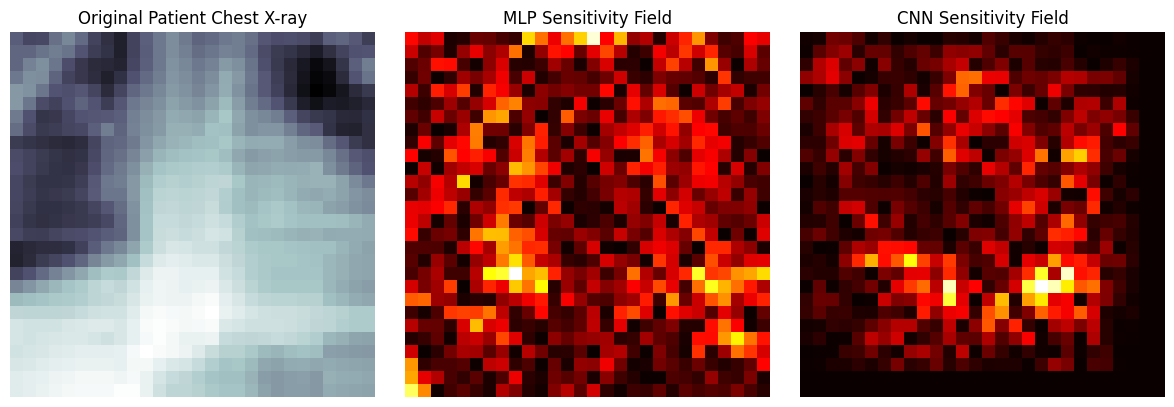

In [9]:
# Choose an index representing a positive Pneumonia case for clear diagnostic visualization
sample_idx = 3  # You can cycle this index to check other clinical cases
raw_img = x_train[sample_idx]
true_lbl = y_train[sample_idx]

print(f"Target Case Index: {sample_idx} | True Status: {label_map[true_lbl]}")

# Compute sensitivity profiles for both competing networks
mlp_saliency = calculate_input_saliency(mlp_model, raw_img, target_class=true_lbl)
cnn_saliency = calculate_input_saliency(cnn_model, raw_img, target_class=true_lbl)

# Render comparative clinical evaluation layout
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(raw_img, cmap='bone')
axes[0].set_title("Original Patient Chest X-ray")
axes[0].axis('off')

axes[1].imshow(mlp_saliency, cmap='hot')
axes[1].set_title("MLP Sensitivity Field")
axes[1].axis('off')

axes[2].imshow(cnn_saliency, cmap='hot')
axes[2].set_title("CNN Sensitivity Field")
axes[2].axis('off')

plt.tight_layout()
plt.show()

Target Case Index: 3 | True Status: Pneumonia


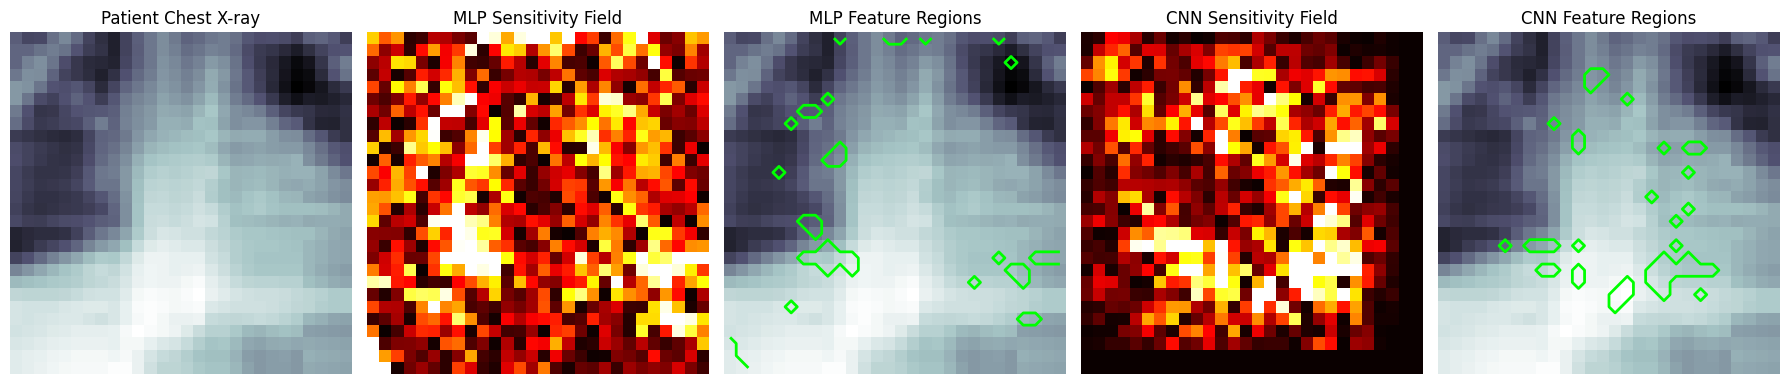

In [10]:
# Choose an index representing a positive Pneumonia case for clear diagnostic visualization
sample_idx = 3  # You can cycle this index to check other clinical cases
raw_img = x_train[sample_idx]
true_lbl = y_train[sample_idx]

print(f"Target Case Index: {sample_idx} | True Status: {label_map[true_lbl]}")

# Compute sensitivity profiles for both competing networks
mlp_saliency = calculate_input_saliency(mlp_model, raw_img, target_class=true_lbl)
cnn_saliency = calculate_input_saliency(cnn_model, raw_img, target_class=true_lbl)

# Helper function to normalize gradients and isolate the top 5% feature mask
def process_saliency_contour(saliency_map, percentile=95):
    # Find the threshold value for the top 5% highest gradients
    v_max = np.percentile(saliency_map, percentile)
    
    # Clip outlier spikes and scale cleanly between [0, 1] relative to that threshold
    clipped = np.clip(saliency_map, 0, v_max)
    normalized = clipped / (v_max + 1e-8)
    
    # Create a binary mask where 1.0 represents the highest-importance regions
    importance_mask = (saliency_map >= v_max).astype(float)
    return normalized, importance_mask

# Process both maps
mlp_norm, mlp_mask = process_saliency_contour(mlp_saliency)
cnn_norm, cnn_mask = process_saliency_contour(cnn_saliency)

# Render comparative clinical evaluation layout (changing from a 1x3 grid to a 1x5 grid)
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# 1. Original Scan
axes[0].imshow(raw_img, cmap='bone')
axes[0].set_title("Patient Chest X-ray")
axes[0].axis('off')

# 2. MLP Heatmap
axes[1].imshow(mlp_norm, cmap='hot', vmin=0, vmax=1)
axes[1].set_title("MLP Sensitivity Field")
axes[1].axis('off')

# 3. MLP Green Contour Overlay
axes[2].imshow(raw_img, cmap='bone')
if np.max(mlp_mask) > 0:
    axes[2].contour(mlp_mask, levels=[0.5], colors='lime', linewidths=2.0)
axes[2].set_title("MLP Feature Regions")
axes[2].axis('off')

# 4. CNN Heatmap
axes[3].imshow(cnn_norm, cmap='hot', vmin=0, vmax=1)
axes[3].set_title("CNN Sensitivity Field")
axes[3].axis('off')

# 5. CNN Green Contour Overlay
axes[4].imshow(raw_img, cmap='bone')
if np.max(cnn_mask) > 0:
    axes[4].contour(cnn_mask, levels=[0.5], colors='lime', linewidths=2.0)
axes[4].set_title("CNN Feature Regions")
axes[4].axis('off')

plt.tight_layout()
plt.show()

In [21]:
def compute_grad_cam(model, image, target_class, layer_name='Conv_Layer_2'):
    # 1. Force the model to be 'called' by passing a dummy image once if needed
    # (This ensures the internal layers are fully initialized)
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    image_tensor = tf.expand_dims(image_tensor, axis=0)
    
    # 2. Get the specific layer object and its output
    target_layer = model.get_layer(layer_name)
    
    with tf.GradientTape() as tape:
        # We need to trace the path from input to the target layer, then to the end
        # We store the intermediate 'conv_outputs' for the tape to track
        x = image_tensor
        conv_outputs = None
        
        for layer in model.layers:
            x = layer(x)
            if layer.name == layer_name:
                conv_outputs = x
        
        predictions = x
        class_score = predictions[0, target_class]
        
    # 3. Calculate gradients
    grads = tape.gradient(class_score, conv_outputs)
    
    # 4. Global Average Pooling (Weights)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # 5. Weighted combination
    conv_outputs = conv_outputs[0]
    grad_cam_map = np.zeros(conv_outputs.shape[0:2], dtype=np.float32)
    
    for i, w in enumerate(weights):
        grad_cam_map += w * conv_outputs[:, :, i]
        
    # 6. Rectify and Normalize
    grad_cam_map = np.maximum(grad_cam_map, 0)
    if np.max(grad_cam_map) > 0:
        grad_cam_map = grad_cam_map / np.max(grad_cam_map)
        
    return grad_cam_map

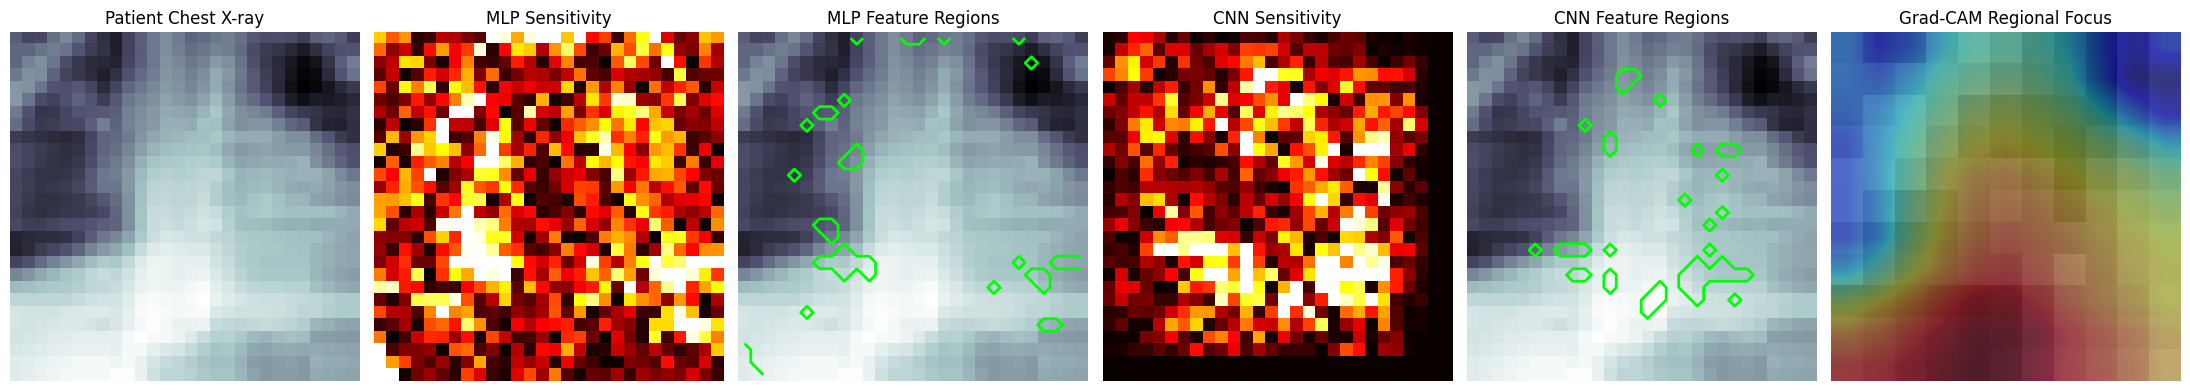

In [22]:
# Compute Grad-CAM
grad_cam_map = compute_grad_cam(cnn_model, raw_img, target_class=true_lbl, layer_name='Conv_Layer_2')

# Render layout (1x6 grid)
fig, axes = plt.subplots(1, 6, figsize=(22, 4))

# 1. Original Scan
axes[0].imshow(raw_img, cmap='bone')
axes[0].set_title("Patient Chest X-ray")
axes[0].axis('off')

# 2. MLP Heatmap
axes[1].imshow(mlp_norm, cmap='hot', vmin=0, vmax=1)
axes[1].set_title("MLP Sensitivity")
axes[1].axis('off')

# 3. MLP Contours
axes[2].imshow(raw_img, cmap='bone')
if np.max(mlp_mask) > 0: axes[2].contour(mlp_mask, levels=[0.5], colors='lime', linewidths=2.0)
axes[2].set_title("MLP Feature Regions")
axes[2].axis('off')

# 4. CNN Heatmap
axes[3].imshow(cnn_norm, cmap='hot', vmin=0, vmax=1)
axes[3].set_title("CNN Sensitivity")
axes[3].axis('off')

# 5. CNN Contours
axes[4].imshow(raw_img, cmap='bone')
if np.max(cnn_mask) > 0: axes[4].contour(cnn_mask, levels=[0.5], colors='lime', linewidths=2.0)
axes[4].set_title("CNN Feature Regions")
axes[4].axis('off')

# 6. Grad-CAM Regional Focus
axes[5].imshow(raw_img, cmap='bone')
axes[5].imshow(grad_cam_map, cmap='jet', alpha=0.4, interpolation='bilinear')
axes[5].set_title("Grad-CAM Regional Focus")
axes[5].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# This prints your model architecture and the exact name of every layer
cnn_model.summary()

Model: "Clinical_Spatial_Prior_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Layer_1 (Conv2D)           │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling_1 (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_Layer_2 (Conv2D)           │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pooling_2 (MaxPooling2D)    │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Bridge (Dense)            │ (None, 32)             │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Simplex (Dense)          │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,496 (357.41 KB)

 Trainable params: 30,498 (119.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 60,998 (238.28 KB)

## 5. Quantitative Analytics & Classroom Discussion Prompts
---

### 💬 Workshop Inferences for Group Discussion:

1. **Anatomical Grounding vs. Pixel Memorization:** Examine the MLP map. Do you see high sensitivity dots flashing outside the body, along the corner borders, or on healthy bones? Why does the lack of a spatial prior lead the MLP to rely on ungrounded pixel coordinates rather than localized lung tissue zones?

2. **Analyzing Diagnostic Misses (Class Exercise):** Locate an index in the test split where the model misinterprets a scan (e.g., a standard lung misclassified as Pneumonia). Adjust the script to compute the saliency map for the *incorrect choice*. Does the gradient reveal that a normal anatomical variation or a physical imaging artifact misled the filters?

3. **Applied Math Sensitivity Context:** How does calculating the input gradient $\nabla_{\mathbf{x}} S_c(\mathbf{x}_0)$ map to traditional parametric sensitivity analysis or Jacobian fields $\mathbf{J}$ used when diagnosing stability boundaries within dynamical systems or biological ODE networks?